Found 3008 files belonging to 2 classes.
Classes: ['Normal Chest X-rays', 'TB Chest X-rays']


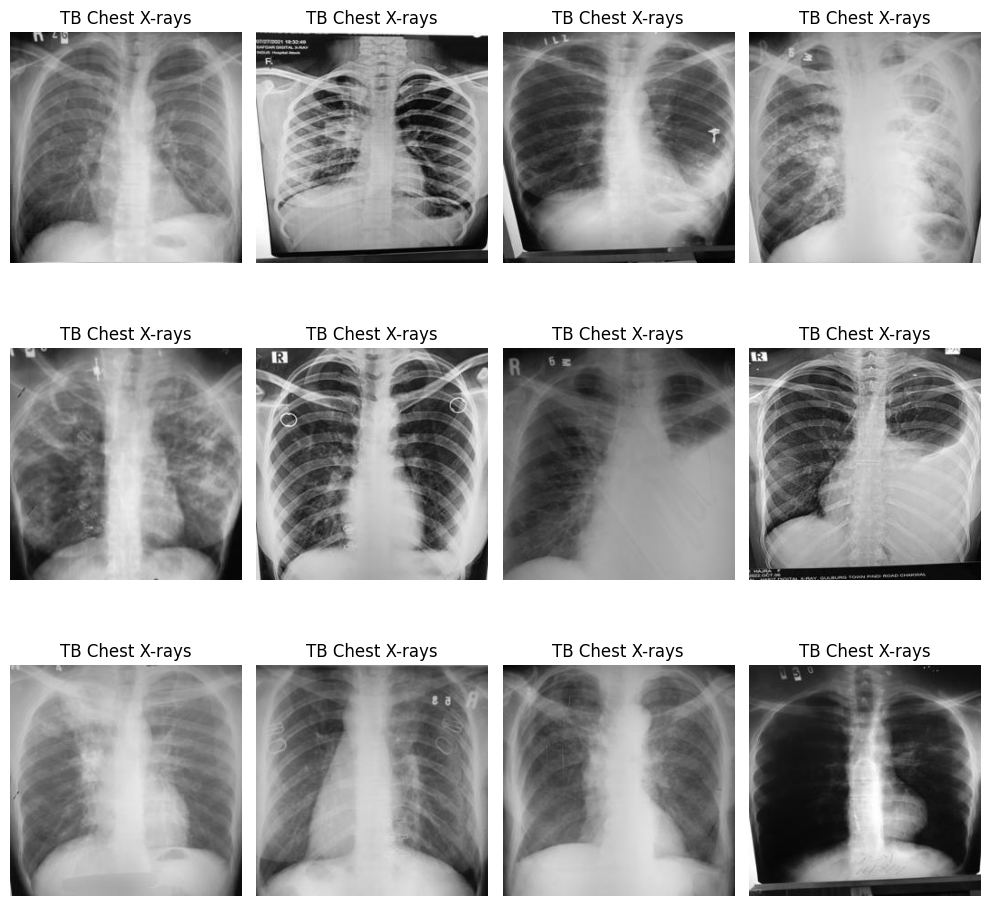

Epoch 1/25


c:\Users\MANAV\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.8037 - loss: 0.8345 - val_accuracy: 0.8021 - val_loss: 0.6719
Epoch 2/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.8559 - loss: 0.5210 - val_accuracy: 0.9757 - val_loss: 0.4805
Epoch 3/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.8892 - loss: 0.4163 - val_accuracy: 0.9757 - val_loss: 0.3657
Epoch 4/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.9353 - loss: 0.3297 - val_accuracy: 0.9479 - val_loss: 0.2967
Epoch 5/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.9422 - loss: 0.3026 - val_accuracy: 0.9757 - val_loss: 0.2539
Epoch 6/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.9538 - loss: 0.2626 - val_accuracy: 0.9618 - val_loss: 0.2411
Epoch 7/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.9517 - loss: 0.2446 - val_accuracy: 0.9792 - val_loss: 0.2387
Epoch 8/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.9582 - loss: 0.2329 - val_accuracy: 0.9792 - val_loss: 0.

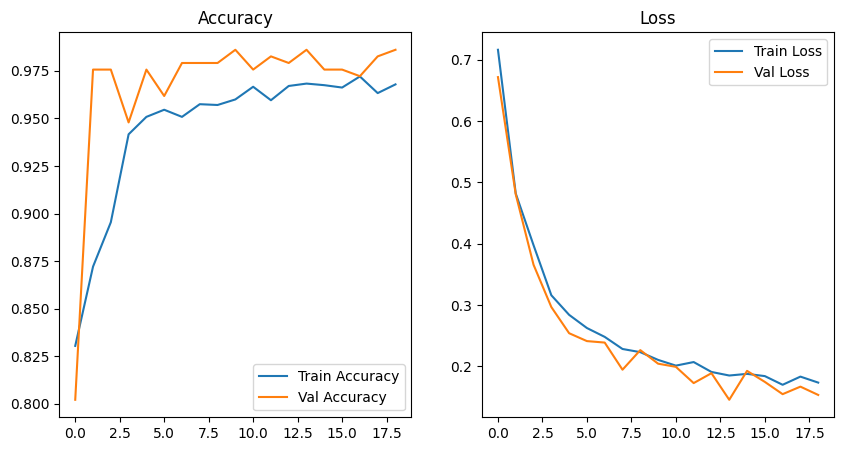

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step
Predicted: TB Chest X-rays
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


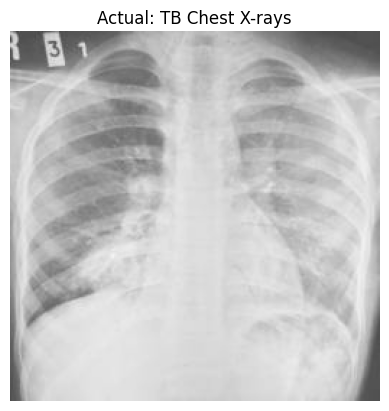

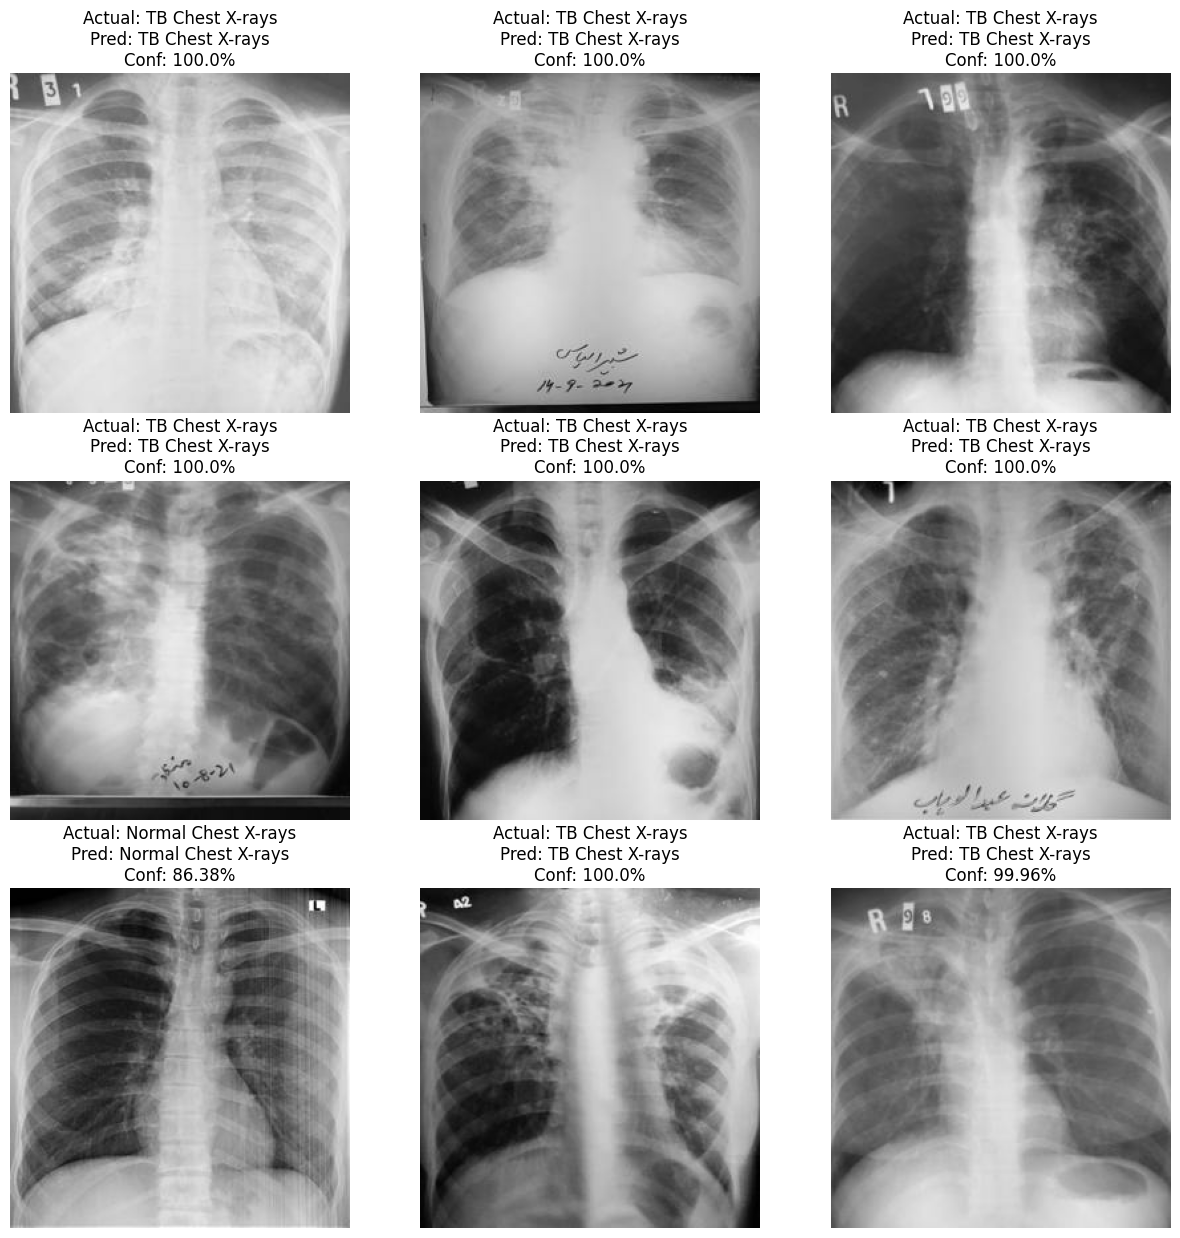

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
import matplotlib.pyplot as plt
import numpy as np
import random
import json

# Configuration
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 25

# Load dataset
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "data",  # structure: data/TB, data/Normal
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

class_names = dataset.class_names
print("Classes:", class_names)

# Save class names for later use in Streamlit app
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

# Collect a batch of images and labels
all_images = []
all_labels = []
for image_batch, label_batch in dataset.take(5):
    for img, lbl in zip(image_batch, label_batch):
        all_images.append(img)
        all_labels.append(lbl.numpy())

# Randomly select 12 indices for visualization
random_indices = random.sample(range(len(all_images)), 12)
plt.figure(figsize=(10, 10))
for i, idx in enumerate(random_indices):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(all_images[idx].numpy().astype("uint8"))
    plt.title(class_names[all_labels[idx]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# Split dataset
def get_dataset_partition_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1):
    ds = ds.shuffle(1000)
    ds_size = tf.data.experimental.cardinality(ds).numpy()
    train_size = int(ds_size * train_split)
    val_size = int(ds_size * val_split)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size + val_size)

    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = get_dataset_partition_tf(dataset)

# Prefetch and cache
train_ds = train_ds.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(tf.data.AUTOTUNE)

# Rescale layer
resize_and_rescale = tf.keras.Sequential([
    layers.Rescaling(1.0 / 255)
])

# Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

# Apply augmentation to training data
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# Model definition
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
model = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001), input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate
scores = model.evaluate(test_ds)
print("Test Loss:", scores[0])
print("Test Accuracy:", scores[1])

# Plot accuracy & loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

# Predict one sample
for image_batch, labels_batch in test_ds.take(1):
    first_image = image_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()

    plt.imshow(first_image)
    plt.title(f"Actual: {class_names[first_label]}")
    plt.axis("off")

    prediction = model.predict(tf.expand_dims(image_batch[0], axis=0))
    predicted_class = class_names[int(np.round(prediction[0][0]))]
    print(f"Predicted: {predicted_class}")

# Predict function
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)
    predicted_class = class_names[int(np.round(predictions[0][0]))]
    confidence = round(100 * float(predictions[0][0]), 2) if predicted_class == class_names[1] else round(100 * (1 - float(predictions[0][0])), 2)
    return predicted_class, confidence

# Display multiple predictions
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]
        plt.title(f"Actual: {actual_class}\nPred: {predicted_class}\nConf: {confidence}%")
        plt.axis("off")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


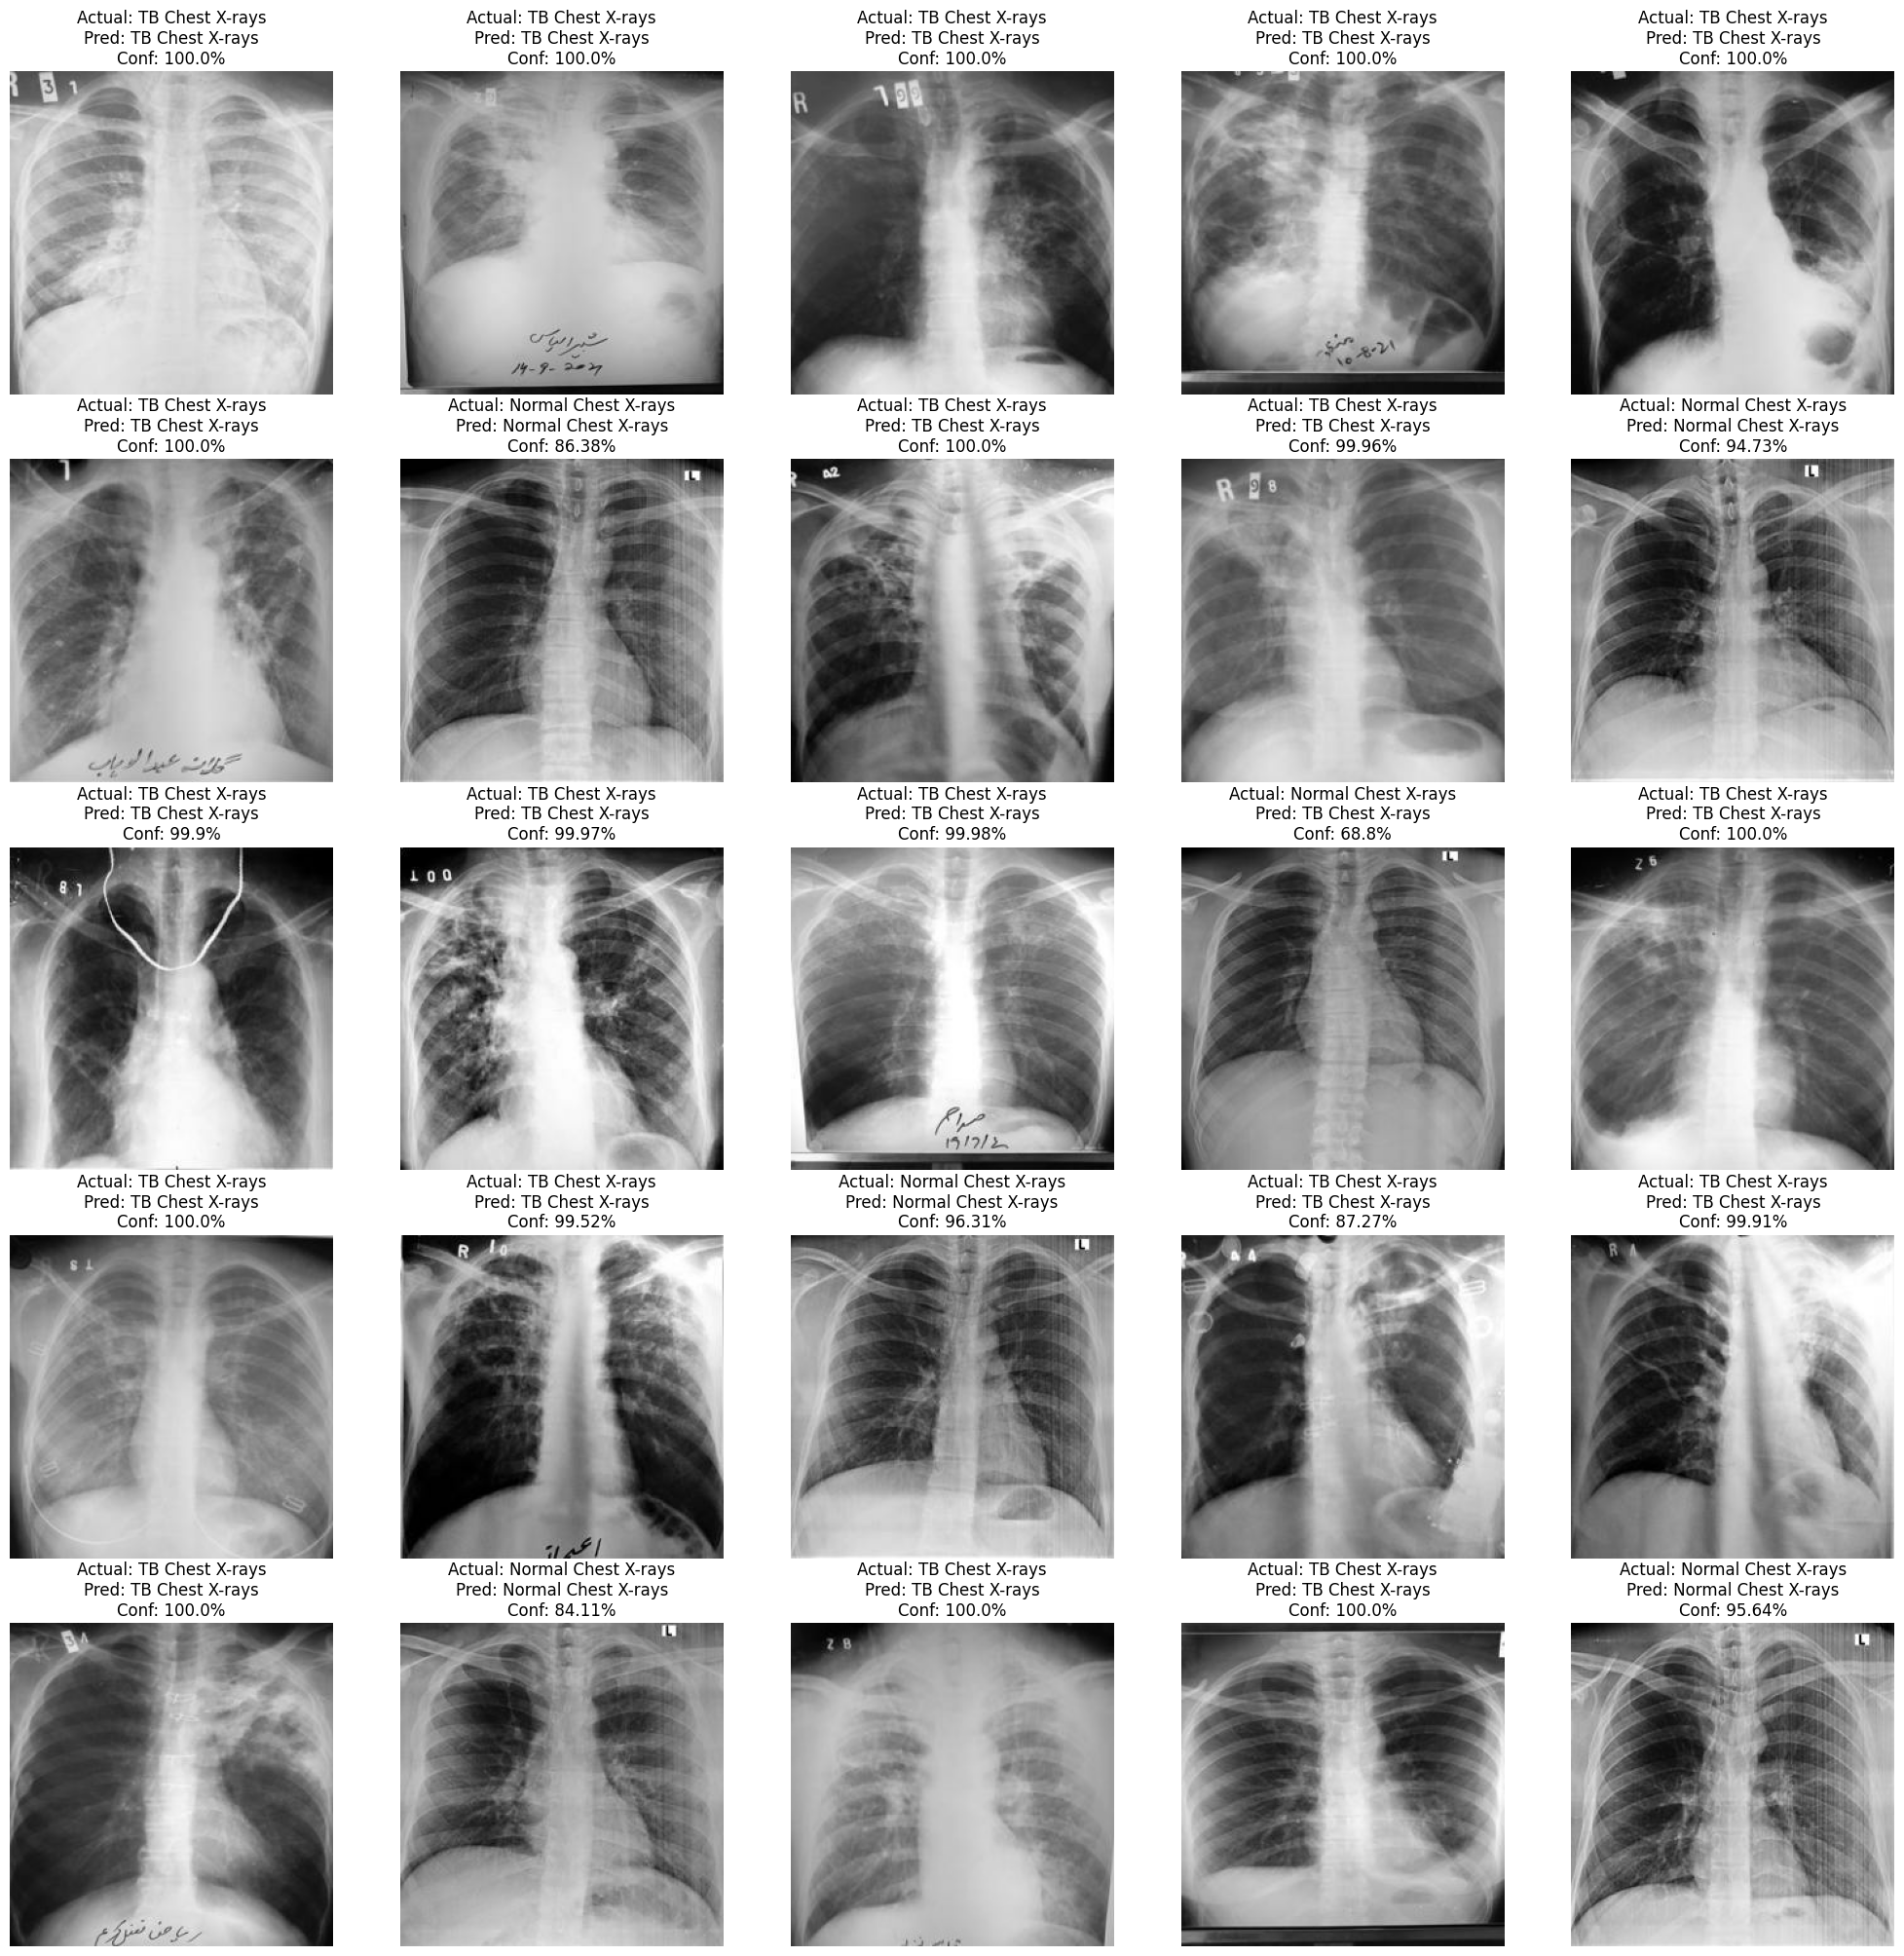

In [6]:
plt.figure(figsize=(25, 25))
for images, labels in test_ds.take(1):
    for i in range(25):
        ax = plt.subplot(5, 5, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]
        plt.title(f"Actual: {actual_class}\nPred: {predicted_class}\nConf: {confidence}%")
        plt.axis("off")

In [2]:
import json

# Save class names to file
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

In [7]:
from tensorflow.keras.saving import save_model
save_model(model, "tb_classifier_model.keras")